## Step 5 : EDA 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
filepath = '../Project_btc_sentiment/btc_sentiment_2017_2026.csv'

In [3]:
sns.set_theme(context='notebook', style = 'white') 
theme = ['#8BBF9F','#59344F','#857E7B','#D6BA73','#F4A259','#E15A97','#FF7F11','#A5CC6B']

In [4]:
df = pd.read_csv(filepath, index_col='Unnamed: 0')

In [5]:
df.head(2)

,sentiment,Date,Open,High,Low,Close,Volume
2017-01-01,0.514342,2017-01-01 00:00:00+00:00,963.658020,1003.080017,958.698975,998.325012,147775008
2017-01-02,0.000000,2017-01-02 00:00:00+00:00,998.617004,1031.390015,996.702026,1021.750000,222184992


In [6]:
df.index = pd.to_datetime(df.index)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3389 entries, 2017-01-01 to 2026-04-12
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sentiment  3072 non-null   float64
 1   Date       3389 non-null   object 
 2   Open       3389 non-null   float64
 3   High       3389 non-null   float64
 4   Low        3389 non-null   float64
 5   Close      3389 non-null   float64
 6   Volume     3389 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 211.8+ KB


### Check for missing value

In [8]:
null_value = df.isnull().sum()
null_value_pct = (null_value/len(df))*100
print(null_value_pct)
print(f'{'='*40}')
print(f"Since the null value percentage is more than 5% for sentiment column, we can't drop it")

sentiment    9.353792
Date         0.000000
Open         0.000000
High         0.000000
Low          0.000000
Close        0.000000
Volume       0.000000
dtype: float64
Since the null value percentage is more than 5% for sentiment column, we can't drop it


In [9]:
df_null = df[df['sentiment'].isnull()]

In [10]:
df_null.shape

(317, 7)

In [11]:
df_null.head(2)

,sentiment,Date,Open,High,Low,Close,Volume
2017-01-08,NaN,2017-01-08 00:00:00+00:00,908.174988,942.723999,887.249023,911.198975,158715008
2017-02-18,NaN,2017-02-18 00:00:00+00:00,1049.209961,1061.099976,1046.959961,1054.420044,99073504


In [12]:
# Check the day in week where sentiment is null
df_null['dayname'] = df_null.index.day_name()
df_null['dayname'].value_counts()

C:\Users\user\AppData\Local\Temp\ipykernel_24508\2268845773.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_null['dayname'] = df_null.index.day_name()


dayname
Saturday    164
Sunday      146
Monday        4
Tuesday       2
Friday        1
Name: count, dtype: int64

In [13]:
print(f"Most of the null values fall on Saturday and Sunday, most likely no news published on weekend.")
print(f'Since we decided not to drop, will forward fill the empty sentiment.')

Most of the null values fall on Saturday and Sunday, most likely no news published on weekend.
Since we decided not to drop, will forward fill the empty sentiment.


In [14]:
# forward fill the sentiment column 
df = df.sort_index()
df['sentiment'] = df['sentiment'].fillna(method ='ffill')

C:\Users\user\AppData\Local\Temp\ipykernel_24508\4195014042.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['sentiment'] = df['sentiment'].fillna(method ='ffill')


In [15]:
df.isnull().sum()

sentiment    0
Date         0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

### Check for duplicated rows

In [16]:
df.duplicated().sum() 

np.int64(0)

## EDA for daily data

In [17]:
# Compute date features 
df['year'] = df.index.year 
df['month'] =df.index.month 
df['quarter'] = df.index.quarter 
df['weekno'] = df.index.isocalendar().week 
df['pct_change_1d'] = df['Close'].pct_change(periods = 1).mul(100)
df['pct_change_7d'] = df['Close'].pct_change(periods = 7).mul(100)
df['pct_change_30d'] = df['Close'].pct_change(periods = 30).mul(100)

In [18]:
df.head(10)

,sentiment,Date,Open,High,Low,Close,Volume,year,month,quarter,weekno,pct_change_1d,pct_change_7d,pct_change_30d
2017-01-01,0.514342,2017-01-01 00:00:00+00:00,963.658020,1003.080017,958.698975,998.325012,147775008,2017,1,1,52,NaN,NaN,NaN
2017-01-02,0.000000,2017-01-02 00:00:00+00:00,998.617004,1031.390015,996.702026,1021.750000,222184992,2017,1,1,1,2.346429,NaN,NaN
2017-01-03,0.212881,2017-01-03 00:00:00+00:00,1021.599976,1044.079956,1021.599976,1043.839966,185168000,2017,1,1,1,2.161974,NaN,NaN
2017-01-04,0.035045,2017-01-04 00:00:00+00:00,1044.400024,1159.420044,1044.400024,1154.729980,344945984,2017,1,1,1,10.623277,NaN,NaN
2017-01-05,-0.292192,2017-01-05 00:00:00+00:00,1156.729980,1191.099976,910.416992,1013.380005,510199008,2017,1,1,1,-12.240955,NaN,NaN
2017-01-06,-0.253135,2017-01-06 00:00:00+00:00,1014.239990,1046.810059,883.943970,902.200989,351876000,2017,1,1,1,-10.971108,NaN,NaN
2017-01-07,0.106364,2017-01-07 00:00:00+00:00,903.487000,908.585022,823.556030,908.585022,279550016,2017,1,1,1,0.707607,NaN,NaN
2017-01-08,0.106364,2017-01-08 00:00:00+00:00,908.174988,942.723999,887.249023,911.198975,158715008,2017,1,1,1,0.287695,-8.727222,NaN
2017-01-09,-0.154979,2017-01-09 00:00:00+00:00,913.244019,913.685974,879.807007,902.828003,141876992,2017,1,1,2,-0.918677,-11.639050,NaN
2017-01-10,0.531205,2017-01-10 00:00:00+00:00,902.440002,914.872986,901.059998,907.679016,115808000,2017,1,1,2,0.537313,-13.044236,NaN


In [19]:
cols = ['Open','High','Low','Close','Volume','sentiment', 'pct_change_1d','pct_change_7d','pct_change_30d'] 

In [20]:
df[cols].describe()

,Open,High,Low,Close,Volume,sentiment,pct_change_1d,pct_change_7d,pct_change_30d
count,3389.000000,3389.000000,3389.000000,3389.000000,3.389000e+03,3389.000000,3388.000000,3382.000000,3359.000000
mean,34828.807581,35524.951920,34087.289433,34848.148921,2.758980e+10,-0.010111,0.190728,1.358259,6.460958
std,32519.114278,33049.558962,31943.605083,32519.180975,2.257350e+10,0.317259,3.591967,9.798082,24.301643
min,775.177979,823.307007,755.755981,777.757019,6.085170e+07,-0.974467,-37.169539,-45.248177,-60.316825
25%,8200.000000,8320.824219,7965.976074,8205.167969,1.108310e+10,-0.190203,-1.359607,-3.750258,-8.192367
50%,23341.039062,23880.632812,22961.279297,23389.433594,2.402624e+10,0.000000,0.102751,0.611815,2.068405
75%,56907.964844,58239.195312,55071.113281,56977.703125,3.836503e+10,0.161521,1.687850,5.859393,17.854618
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11,0.956873,25.247169,74.911076,192.692370


### 1) To check distribution of columns of interest

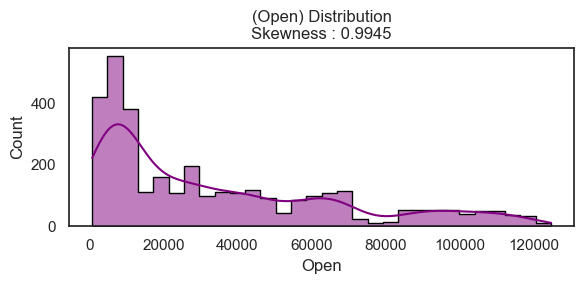

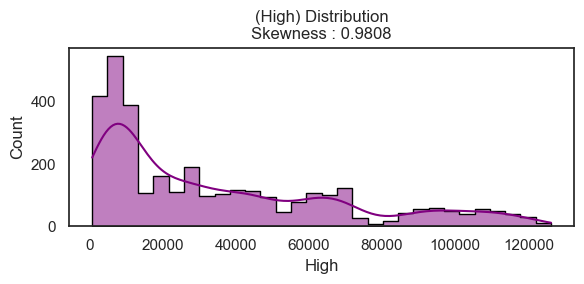

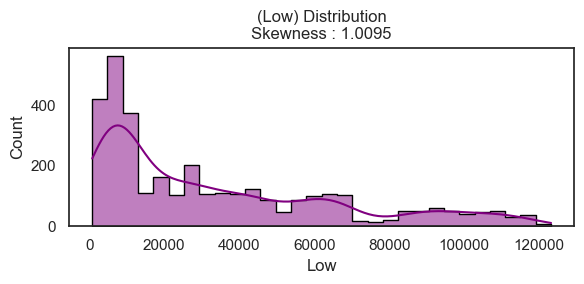

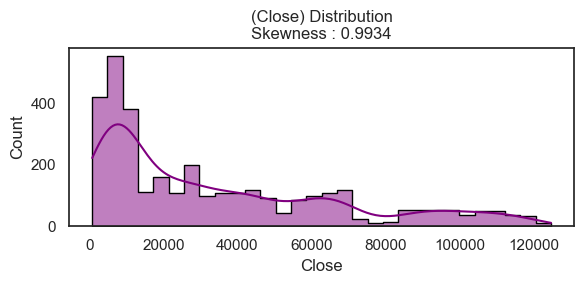

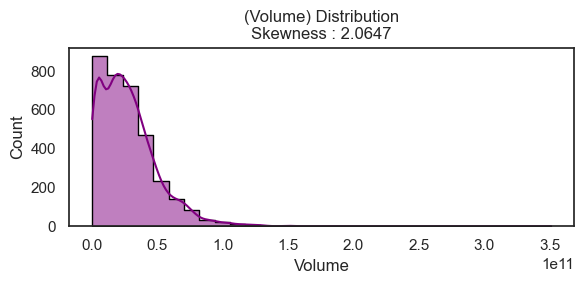

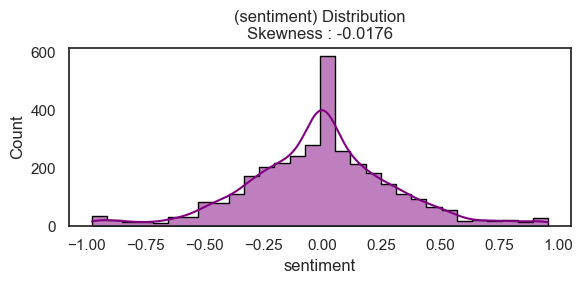

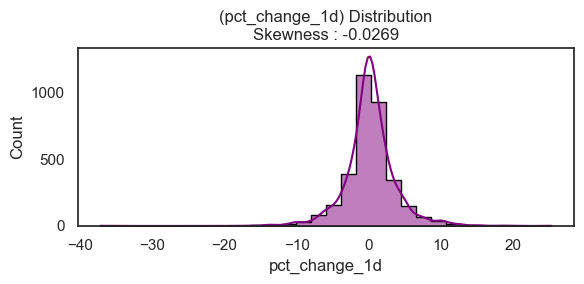

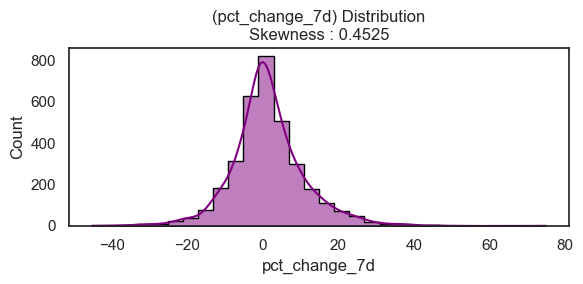

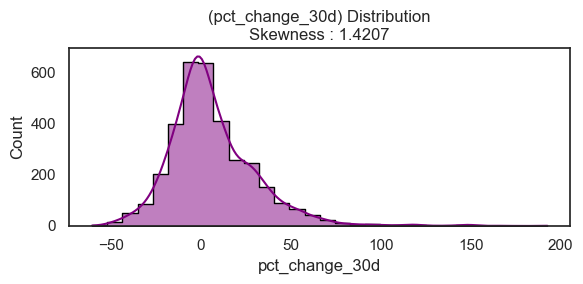

In [21]:
for i, col in enumerate(cols) :
    col_skew = df[col].skew()
    plt.figure(figsize = (6,3))
    sns.histplot(data = df , x = col, alpha = 0.5, color = 'purple' , bins = 30, element = 'step', kde = True, edgecolor = 'black')
    plt.title(f'({col}) Distribution\nSkewness : {col_skew:.4f}')
    plt.tight_layout()
    plt.show()

### 2). Checking correlation for columns of interest

<Figure size 1200x800 with 0 Axes>

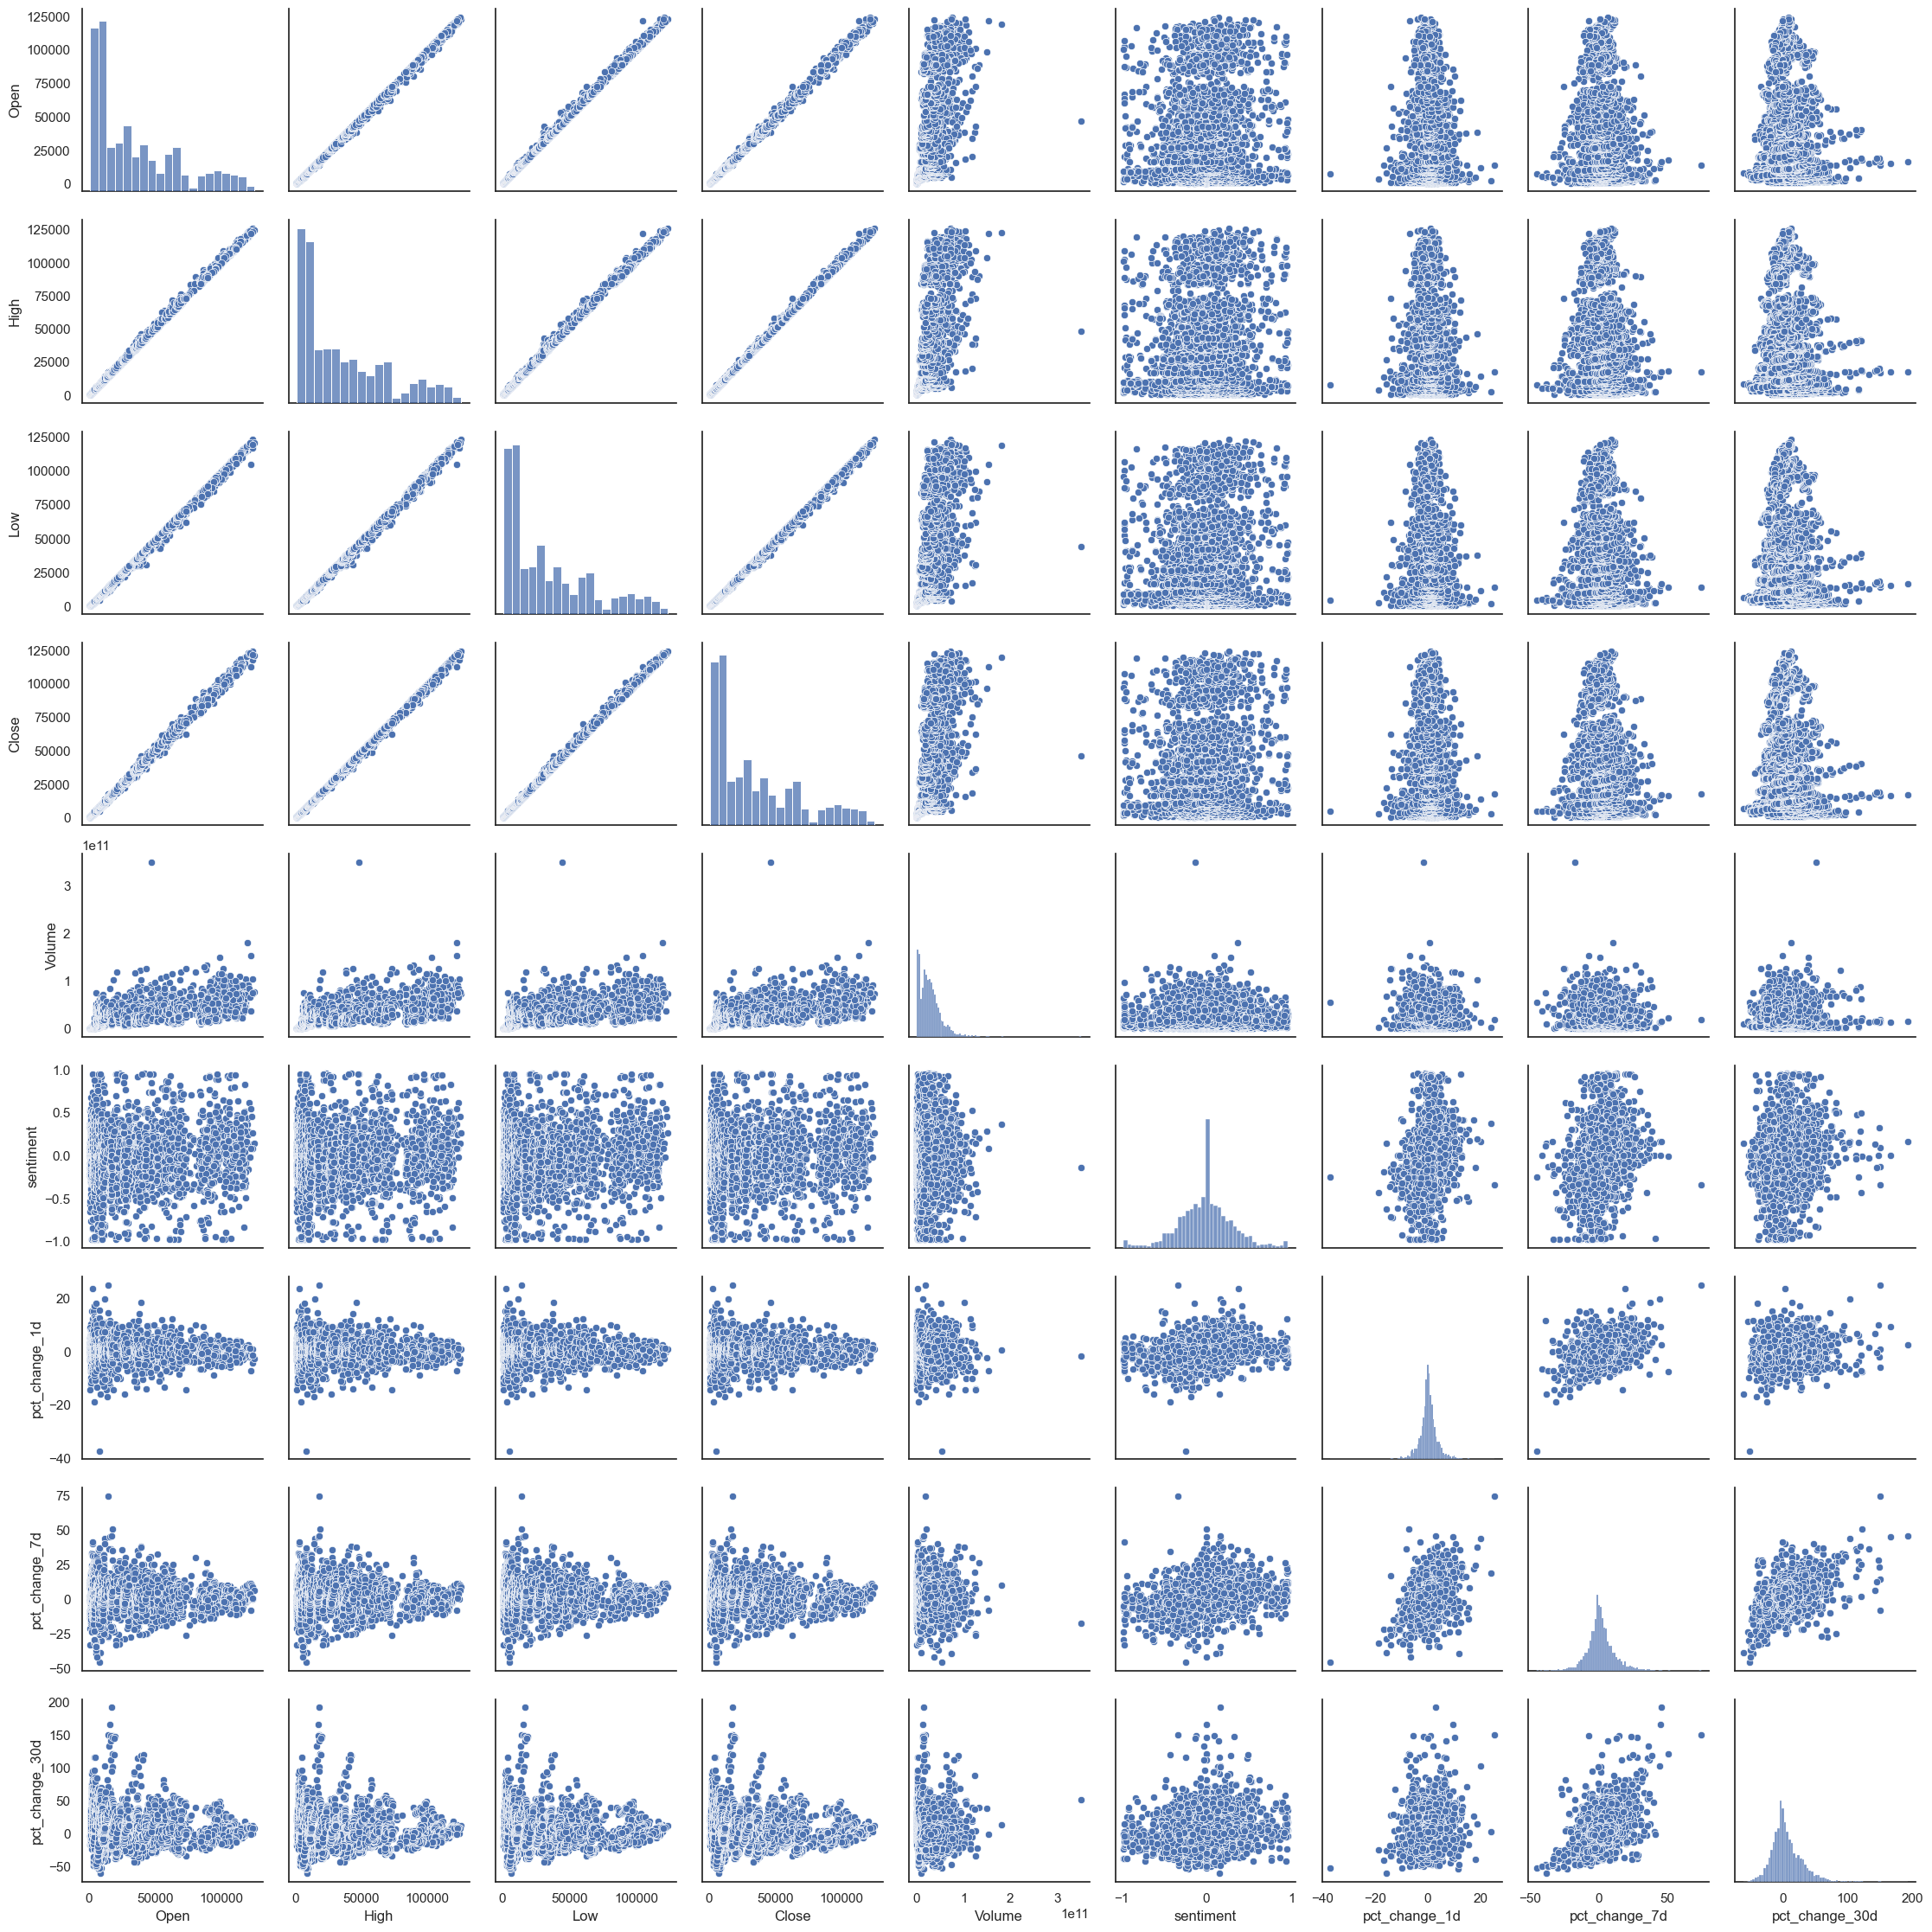

In [22]:
# pairplot to check linear relationship between 2 variables
plt.figure(figsize=(12,8))
sns.pairplot(df[cols])
plt.tight_layout() 
plt.show()

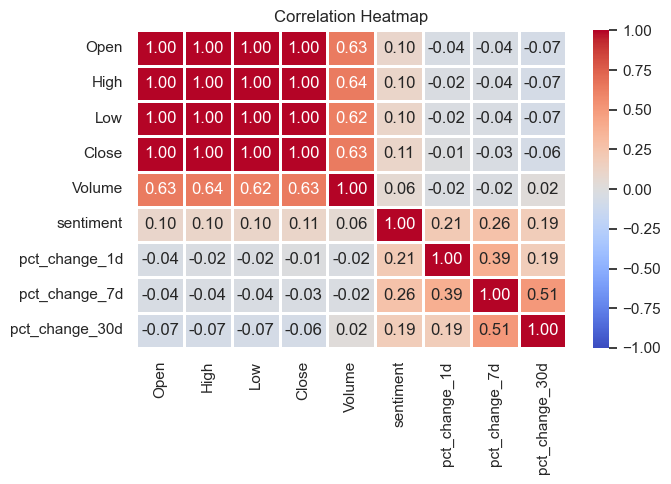

In [23]:
# calculate correlation
correlation_matrix = df[cols].corr()

# plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(correlation_matrix, annot= True, fmt='.2f', 
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=1)
plt.title('Correlation Heatmap')
plt.tight_layout() 
plt.show()

In [24]:
print(f'Sentiment show mild correlation with percentage change 7d > 1d > 30d.')

Sentiment show mild correlation with percentage change 7d > 1d > 30d.


### 3) Line plot, to check visually monthly seasonality

In [25]:
# filter data by years
df_2017_2020 = df.loc['2017-01-01':'2020-12-31']
df_2021_2025 = df.loc['2021-01-01':'2025-12-31'] 
month_order = list(range(1, 13))

# Aggregate data into 2 portions
# 2017 - 2020
month_line_2017_2020 = df_2017_2020.groupby(['year','month']).agg(
    sentiment=('sentiment','mean'), 
    close_price=('Close','last')
).reset_index()

month_line_2017_2020['month'] = pd.Categorical(
    month_line_2017_2020['month'], categories=month_order, ordered=True
)

# 2021 - 2025
month_line_2021_2025 = df_2021_2025.groupby(['year','month']).agg(
    sentiment=('sentiment','mean'), 
    close_price=('Close','last')
).reset_index()

month_line_2021_2025['month'] = pd.Categorical(
    month_line_2021_2025['month'], categories=month_order, ordered=True
)


C:\Users\user\AppData\Local\Temp\ipykernel_24508\2620708151.py:5: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.lineplot(
C:\Users\user\AppData\Local\Temp\ipykernel_24508\2620708151.py:20: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.lineplot(


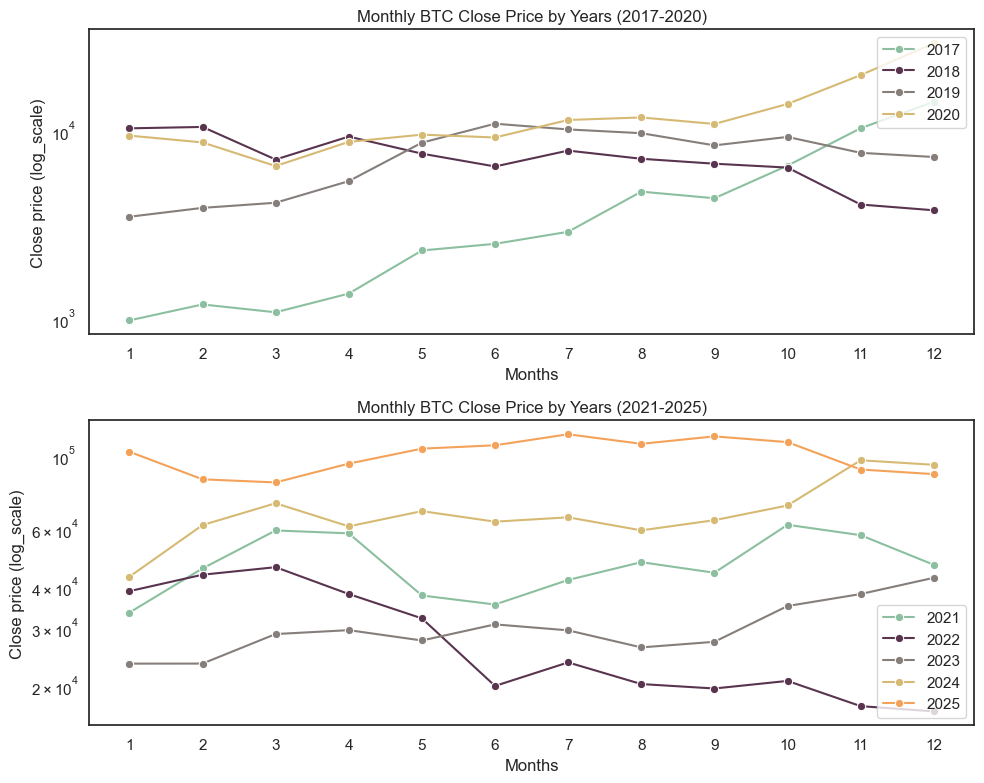

In [26]:
# plot the graph to see monthly trend
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# 1st plot (2017-2020)
sns.lineplot(
    data=month_line_2017_2020, 
    x='month', y='close_price', hue='year', 
    ax=axes[0], marker='o', palette=theme
)
          
axes[0].set(
    title='Monthly BTC Close Price by Years (2017-2020)',
    xlabel='Months',
    ylabel='Close price (log_scale)', 
    xticks = range(1,13) ,
    yscale = 'log') 
axes[0].legend(loc='upper right')

# 2nd plot (2021-2025)
sns.lineplot(
    data=month_line_2021_2025, 
    x='month', y='close_price', hue='year', 
    ax=axes[1], marker='o', palette=theme
)

axes[1].set(
    title='Monthly BTC Close Price by Years (2021-2025)',
    xlabel='Months',
    ylabel='Close price (log_scale)', 
    xticks = range(1,13), 
    yscale = 'log'
)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()


In [27]:
print(f'No obvious seasonal trend in a year based on the monthly BTC price over the different years.')

No obvious seasonal trend in a year based on the monthly BTC price over the different years.


### 4) 1D vs 7D vs 30D return

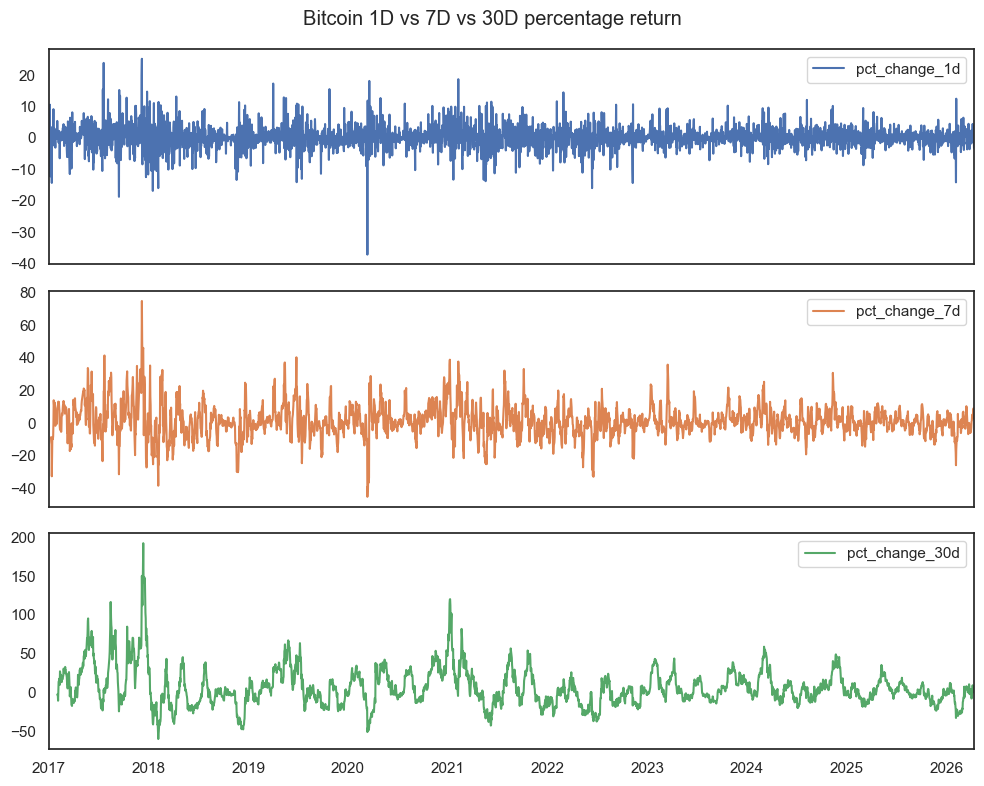

In [28]:
df[['pct_change_1d','pct_change_7d','pct_change_30d']].plot(subplots = True,figsize=(10,8)) 
plt.suptitle('Bitcoin 1D vs 7D vs 30D percentage return')
plt.tight_layout() 
plt.show()

In [29]:
print(f'Visually, btcoin has shown diminished return percentage over the years.')

Visually, btcoin has shown diminished return percentage over the years.


### 5) Bitcoin return% by years

In [30]:
prices = pd.DataFrame()
years_1 = ['2017','2018','2019','2020','2021','2022','2023','2024','2025']

for i in years_1 : 
    yearly_btc = df.loc[i,['Close']].reset_index(drop = True) 
    yearly_btc.rename(columns = {'Close' : i}, inplace = True)
    prices = pd.concat([prices, yearly_btc], axis = 1) 
    

In [31]:
first_prices = prices.iloc[0]
normalized = prices.div(first_prices).mul(100) 

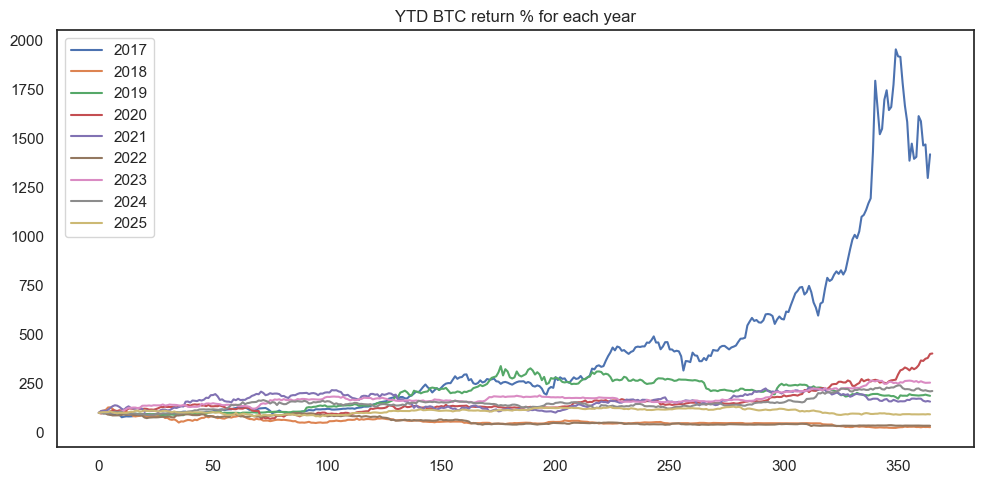

In [32]:
normalized.plot(figsize = (10,5))
plt.title('YTD BTC return % for each year')
plt.tight_layout()
plt.show()

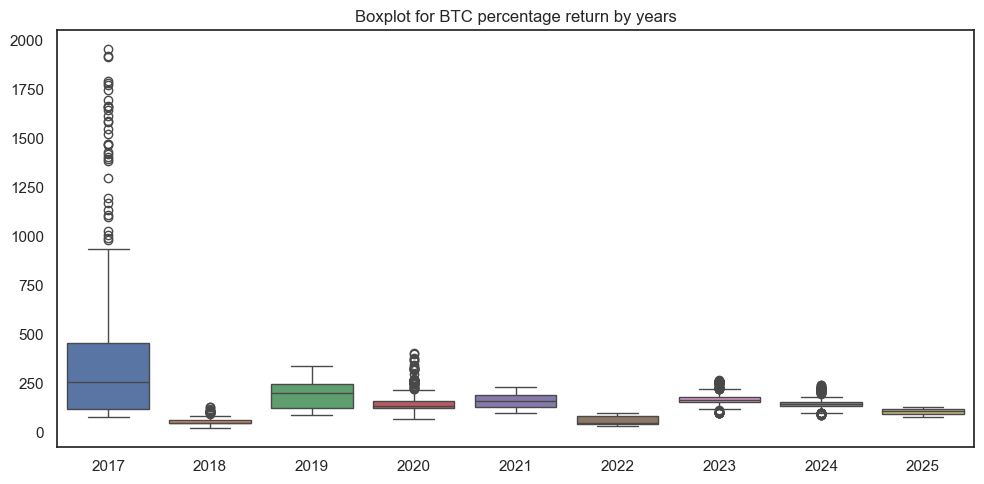

In [33]:
plt.figure(figsize = (10,5))
sns.boxplot(normalized) 
plt.title('Boxplot for BTC percentage return by years')
plt.tight_layout() 
plt.show() 

In [34]:
print(f'Visually, year 2017 yield the widest range of return up to approx 2000%')

Visually, year 2017 yield the widest range of return up to approx 2000%


## EDA for weekly data 
### 1) Aggregating to weekly data

In [35]:
df.head(2)

,sentiment,Date,Open,High,Low,Close,Volume,year,month,quarter,weekno,pct_change_1d,pct_change_7d,pct_change_30d
2017-01-01,0.514342,2017-01-01 00:00:00+00:00,963.658020,1003.080017,958.698975,998.325012,147775008,2017,1,1,52,NaN,NaN,NaN
2017-01-02,0.000000,2017-01-02 00:00:00+00:00,998.617004,1031.390015,996.702026,1021.750000,222184992,2017,1,1,1,2.346429,NaN,NaN


In [36]:
weekly = df.resample('W-FRI').agg(Sentiment = ('sentiment','mean'),  
                                 Open = ('Open', 'first'), 
                                 High = ('High', 'max'), 
                                 Low = ('Low', 'min'), 
                                 Close = ('Close','last'), 
                                 Volume = ('Volume', 'sum')
                            )

In [37]:
weekly['year'] = weekly.index.year.astype(int) 
weekly['month'] = weekly.index.month.astype(int) 
weekly['quarter'] = weekly.index.quarter.astype(int) 
weekly['weekno'] = weekly.index.isocalendar().week.astype(int)
weekly['pct_change_1w'] = weekly['Close'].pct_change(periods = 1).mul(100)
weekly['pct_change_4w'] = weekly['Close'].pct_change(periods = 4).mul(100)
weekly['pct_change_8w'] = weekly['Close'].pct_change(periods = 8).mul(100)

### 2) Check weekly correlation

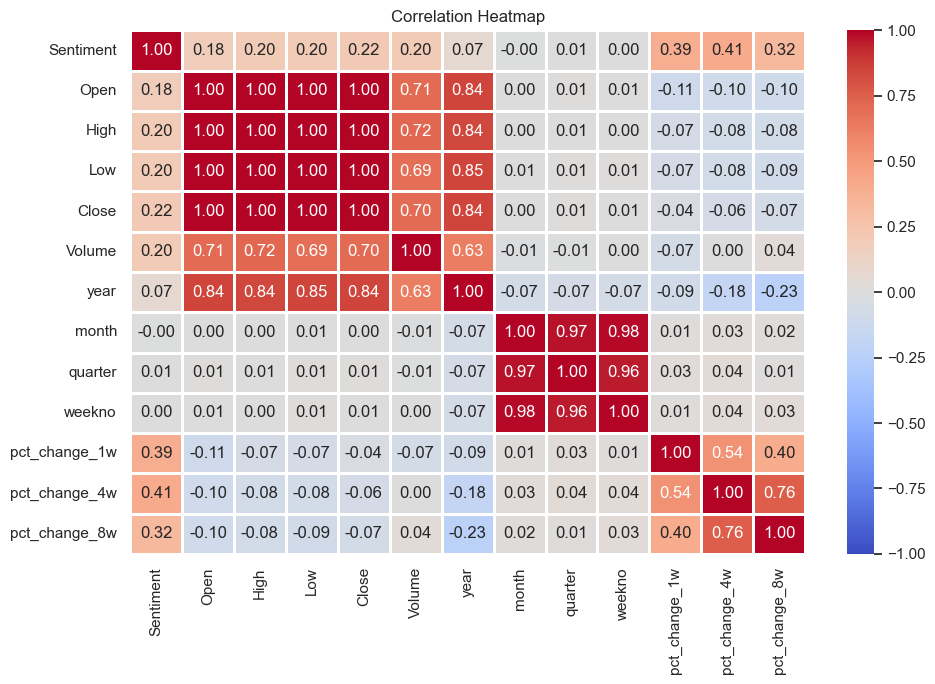

In [38]:
cm_weekly = weekly.corr() 

# plot heatmap
plt.figure(figsize=(10,7))
sns.heatmap(cm_weekly, annot= True, fmt='.2f', 
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=1)
plt.title('Correlation Heatmap')
plt.tight_layout() 
plt.show()

In [39]:
print(f'Weekly sentiment show stonger correlation with weekly return for 1 week and 4 week interval compare to daily data.')

Weekly sentiment show stonger correlation with weekly return for 1 week and 4 week interval compare to daily data.


In [41]:
# save weekply data to csv 
weekly.to_csv('weekly_btc_2017_2026.csv')